## Missing values 
#### Types
#### 1. MCAR : Missing completely at random
#### 2. MAR : Missing at random
#### 3. MNAR : Missing not at random 

In [2]:
import seaborn as sns

In [3]:
df=sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
print(df.shape)
df.isna().sum()

(891, 15)


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
## Delete the rows or datapoints to handle missing value
#df.dropna().shape
# column wise
# df.dropna(axis=1 )

## Imputation Techniques Missing values
##### 1 Mean value Imputation : Mean Imputaion works well when we have normally distributed data
##### 2 Median value Imputaion : if we have outliers in the dataset
##### 3 Mode Imputaion : Categorical Value 
##### 4 Random Sampling Technique 

<Axes: xlabel='age', ylabel='Count'>

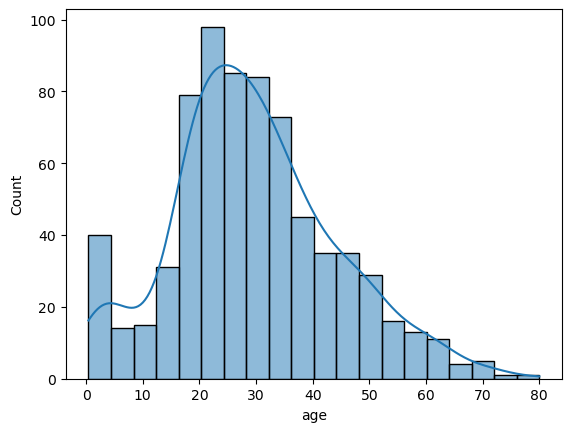

In [6]:
sns.histplot(df['age'], kde=True)

In [7]:
df['Age_mean']=df['age'].fillna(df['age'].mean())
df[['Age_mean','age']]

,Age_mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


<Axes: xlabel='Age_mean', ylabel='Count'>

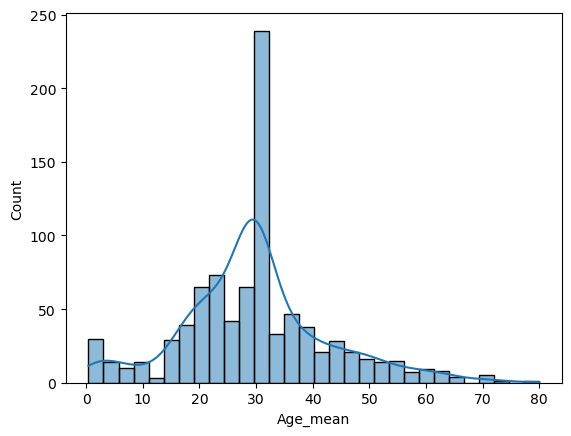

In [8]:
sns.histplot(df['Age_mean'], kde=True)

In [9]:
df['Age_median']=df['age'].fillna(df['age'].median())
df[['Age_median','Age_mean','age']]

,Age_median,Age_mean,age
0,22.0,22.000000,22.0
1,38.0,38.000000,38.0
2,26.0,26.000000,26.0
3,35.0,35.000000,35.0
4,35.0,35.000000,35.0
...,...,...,...
886,27.0,27.000000,27.0
887,19.0,19.000000,19.0
888,28.0,29.699118,NaN
889,26.0,26.000000,26.0


In [10]:
df[df['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age_mean,Age_median
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [11]:
df['embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [12]:
mode=df[df['embarked'].notna()]['embarked'].mode()[0]

In [13]:
df['embarked_mode']=df['embarked'].fillna(mode)

In [14]:
df[['embarked_mode','embarked']]

,embarked_mode,embarked
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


## Handling Imbalanced Data 
##### classification - O/P = Categories
##### Two categories - Binary Classifiaction
##### 1000 datapoints : 900 yes 100 no
##### Ratio = 9:1
##### Model Biased
##### Two techniques : 1. Upsampling              2. Downsampling

In [15]:
import numpy as np
import pandas as pd

np.random.seed(123)

n_sample=1000
class_ratio=0.9
n_class_0=int(n_sample*class_ratio)
n_class_1=n_sample-n_class_0

In [16]:
n_class_0,n_class_1

(900, 100)

In [17]:
#create dataframe with imbalanced Dataset
class_0=pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target':[0]*n_class_0
})
class_1=pd.DataFrame({
    'feature_1': np.random.normal(loc=2, scale=1, size=n_class_1),
    'feature_1': np.random.normal(loc=2, scale=1, size=n_class_1),
    'target':[1]*n_class_1
})

In [18]:
df=pd.concat([class_0,class_1]).reset_index(drop=True)
df.head()

,feature_1,feature_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0


In [19]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [20]:
#Upsampling
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [21]:
from sklearn.utils import resample
df_minority_upsampled=resample(df_minority,replace=True, n_samples=len(df_majority),
         random_state=42)  # sample get added with replacement

In [22]:
df_minority_upsampled.shape

(900, 3)

In [23]:
df_upsampled=pd.concat([df_majority,df_minority_upsampled])

In [24]:
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

In [25]:
# Downsampling
class_0=pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target':[0]*n_class_0
})
class_1=pd.DataFrame({
    'feature_1': np.random.normal(loc=2, scale=1, size=n_class_1),
    'feature_1': np.random.normal(loc=2, scale=1, size=n_class_1),
    'target':[1]*n_class_1
})
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [26]:
from sklearn.utils import resample
df_majority_downsampled=resample(df_majority,replace=False, n_samples=len(df_minority),
         random_state=42)  # sample get added with replacement

In [27]:
df_majority_downsampled.shape

(100, 3)

In [28]:
df_downsampled=pd.concat([df_minority,df_majority_downsampled])

In [29]:
df_downsampled.target.value_counts()

target
1    100
0    100
Name: count, dtype: int64

## SMOTE (Synthetic Minority Oversampling Technique)

In [30]:
# Upsampling Technique : SMOTE (Synthetic Minority Oversampling Technique )
from sklearn.datasets import make_classification
x,y=make_classification(n_samples=1000,n_redundant=0,n_features=2,n_clusters_per_class=1,
                    weights=[0.90],random_state=12)  

In [31]:
df1=pd.DataFrame(x,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
final_df=pd.concat([df1,df2], axis=1)
final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [32]:
final_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

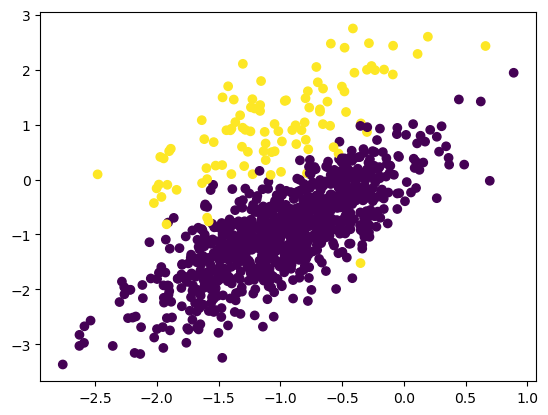

In [33]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'],final_df['f2'], c=final_df['target'])

In [34]:
from imblearn.over_sampling import SMOTE


In [35]:
oversample=SMOTE()
x,y=oversample.fit_resample(final_df[['f1','f2']],final_df['target'])

In [36]:
x.shape

(1800, 2)

In [37]:
y.shape

(1800,)

In [38]:
len(y[y==0])

900

In [39]:
len(y[y==1])

900

In [40]:
df1=pd.DataFrame(x,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
oversample_df=pd.concat([df1,df2], axis=1)

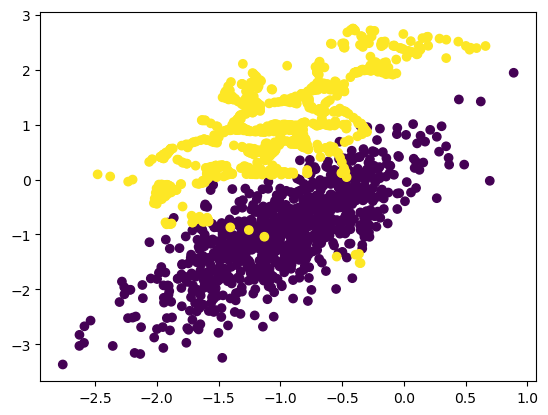

In [41]:
plt.scatter(oversample_df['f1'],oversample_df['f2'],c=oversample_df['target'])

## Handling Outliers in a dataset

In [42]:
# Minimum, Maximum, Median, Q1, Q3, IQR
lst_marks=[45,32,56,75,89,54,32,89,90,87,67,54,45,98,99,67,74]
minimum,maximum,Q1,median,Q3=np.quantile(lst_marks,[0,0.25,0.50,0.75,1.0])

In [43]:
print(minimum)
print(maximum)
print(Q1)
print(median)
print(Q3)

32.0
54.0
67.0
89.0
99.0


In [44]:
IQR=Q3-Q1
print(IQR)

32.0


In [45]:
lower_fence=Q1-1.5*(IQR)
higher_fence=Q3+1.5*(IQR)
print(lower_fence)
print(higher_fence)

19.0
147.0


In [46]:
lst_marks=[-100,-2,-34,45,32,56,75,89,54,32,89,90,87,67,54,45,98,99,67,74,150,200]

<Axes: >

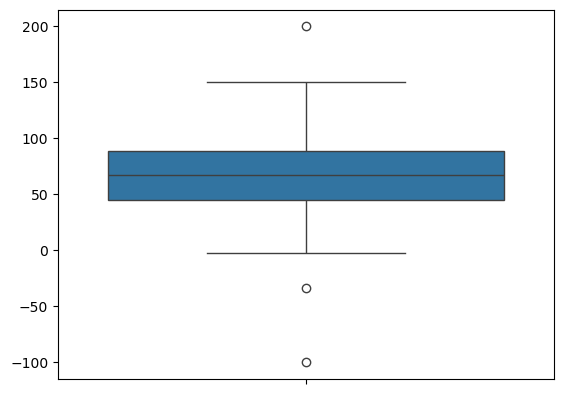

In [47]:
sns.boxplot(lst_marks)

## DATA ENCODING
##### 1. Nominal/OHE Encoding
##### 2. Label and Ordinal Encoding
##### 3. Target Guided Ordinal Encoding

In [48]:
from sklearn.preprocessing import OneHotEncoder 

In [49]:
df=pd.DataFrame({
    'color':['red','blue','green','green','red','blue']
})
df.head()

,color
0,red
1,blue
2,green
3,green
4,red


In [50]:
#create an instance of onehotEncoder
encoder=OneHotEncoder()

In [51]:
# perform fit and then transform
encoded=encoder.fit_transform(df[['color']]).toarray()

In [52]:
encoded_df=pd.DataFrame(encoded,columns=encoder.get_feature_names_out())
encoded_df

,color_blue,color_green,color_red
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,0.0,1.0
5,1.0,0.0,0.0


In [53]:
# for new data
encoder.transform([['blue']]).toarray()

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


array([[1., 0., 0.]])

In [54]:
pd.concat([df,encoded_df], axis=1)

,color,color_blue,color_green,color_red
0,red,0.0,0.0,1.0
1,blue,1.0,0.0,0.0
2,green,0.0,1.0,0.0
3,green,0.0,1.0,0.0
4,red,0.0,0.0,1.0
5,blue,1.0,0.0,0.0


In [55]:
data=sns.load_dataset('tips')
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [56]:
encoded_sex=encoder.fit_transform(data[['sex']]).toarray()
encoded_sex_data=pd.DataFrame(encoded_sex, columns=encoder.get_feature_names_out())
encoded_sex_data


,sex_Female,sex_Male
0,1.0,0.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,1.0,0.0
...,...,...
239,0.0,1.0
240,1.0,0.0
241,0.0,1.0
242,0.0,1.0


In [57]:
encoded_day=encoder.fit_transform(data[['day']]).toarray()
encoder.get_feature_names_out()
encoded_day_data=pd.DataFrame(encoded_day, columns=encoder.get_feature_names_out())
encoded_day_data

,day_Fri,day_Sat,day_Sun,day_Thur
0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0
...,...,...,...,...
239,0.0,1.0,0.0,0.0
240,0.0,1.0,0.0,0.0
241,0.0,1.0,0.0,0.0
242,0.0,1.0,0.0,0.0


In [58]:
encoded_time=encoder.fit_transform(data[['time']]).toarray()
encoded_time_data=pd.DataFrame(encoded_time, columns=encoder.get_feature_names_out())
encoded_time_data

,time_Dinner,time_Lunch
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
...,...,...
239,1.0,0.0
240,1.0,0.0
241,1.0,0.0
242,1.0,0.0


In [59]:
encoded_smoker=encoder.fit_transform(data[['smoker']]).toarray()
encoded_smoker_data=pd.DataFrame(encoded_smoker,columns=encoder.get_feature_names_out())
encoded_smoker_data

,smoker_No,smoker_Yes
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
...,...,...
239,1.0,0.0
240,0.0,1.0
241,0.0,1.0
242,1.0,0.0


In [60]:
final_data=pd.concat([data,encoded_sex_data,encoded_smoker_data,encoded_day_data,encoded_time_data], axis=1)
final_data

,total_bill,tip,sex,smoker,day,time,size,sex_Female,sex_Male,smoker_No,smoker_Yes,day_Fri,day_Sat,day_Sun,day_Thur,time_Dinner,time_Lunch
0,16.99,1.01,Female,No,Sun,Dinner,2,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,10.34,1.66,Male,No,Sun,Dinner,3,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,21.01,3.50,Male,No,Sun,Dinner,3,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,23.68,3.31,Male,No,Sun,Dinner,2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,24.59,3.61,Female,No,Sun,Dinner,4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
240,27.18,2.00,Female,Yes,Sat,Dinner,2,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
241,22.67,2.00,Male,Yes,Sat,Dinner,2,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
242,17.82,1.75,Male,No,Sat,Dinner,2,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


#### Label and Ordinal Encoding

In [61]:
df.head()

,color
0,red
1,blue
2,green
3,green
4,red


In [62]:
from sklearn.preprocessing import LabelEncoder
lbl_encoder=LabelEncoder()
lbl_encoder.fit_transform(df[['color']])

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([2, 0, 1, 1, 2, 0])

In [63]:
lbl_encoder.transform([['red']])

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([2])

#### ordinal Encoding

In [64]:
from sklearn.preprocessing import OrdinalEncoder
df=pd.DataFrame(
    {'size': ['small','medium','large', 'medium', 'small', 'large']}
)
df


,size
0,small
1,medium
2,large
3,medium
4,small
5,large


In [65]:
ord_encoder=OrdinalEncoder(categories=[['small','medium','large']])
ord_encoder.fit_transform(df[['size']])

array([[0.],
       [1.],
       [2.],
       [1.],
       [0.],
       [2.]])

In [66]:
ord_encoder.transform([['large']]) 

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


array([[2.]])

#### Target guided ordinal encoding

In [67]:
data=pd.DataFrame({
    'city':['New York','London','Paris','Tokyo','New York','Paris'],
    'price':[200,250,300,250,180,320]
})
data

,city,price
0,New York,200
1,London,250
2,Paris,300
3,Tokyo,250
4,New York,180
5,Paris,320


In [68]:
mean_price=data.groupby('city')['price'].mean().to_dict()
mean_price

{'London': 250.0, 'New York': 190.0, 'Paris': 310.0, 'Tokyo': 250.0}

In [69]:
data['city_encoded']=data['city'].map(mean_price)
data

,city,price,city_encoded
0,New York,200,190.0
1,London,250,250.0
2,Paris,300,310.0
3,Tokyo,250,250.0
4,New York,180,190.0
5,Paris,320,310.0


In [70]:
data[['price','city_encoded']]

,price,city_encoded
0,200,190.0
1,250,250.0
2,300,310.0
3,250,250.0
4,180,190.0
5,320,310.0


In [71]:
#time on the basis of total bill
df=sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [75]:
mean_totalbill=df.groupby('time')['total_bill'].mean().to_dict()

C:\Users\HP\AppData\Local\Temp\ipykernel_24892\673389659.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_totalbill=df.groupby('time')['total_bill'].mean().to_dict()


In [77]:
df['encoded_time']=df['time'].map(mean_totalbill)
df

,total_bill,tip,sex,smoker,day,time,size,encoded_time
0,16.99,1.01,Female,No,Sun,Dinner,2,20.797159
1,10.34,1.66,Male,No,Sun,Dinner,3,20.797159
2,21.01,3.50,Male,No,Sun,Dinner,3,20.797159
3,23.68,3.31,Male,No,Sun,Dinner,2,20.797159
4,24.59,3.61,Female,No,Sun,Dinner,4,20.797159
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,20.797159
240,27.18,2.00,Female,Yes,Sat,Dinner,2,20.797159
241,22.67,2.00,Male,Yes,Sat,Dinner,2,20.797159
242,17.82,1.75,Male,No,Sat,Dinner,2,20.797159


In [78]:
df[['total_bill','encoded_time']]

,total_bill,encoded_time
0,16.99,20.797159
1,10.34,20.797159
2,21.01,20.797159
3,23.68,20.797159
4,24.59,20.797159
...,...,...
239,29.03,20.797159
240,27.18,20.797159
241,22.67,20.797159
242,17.82,20.797159
